In [1]:
import shutil
from pathlib import Path

import lancedb
from lancedb.rerankers import ColbertReranker

from rag_app import add_data, application, get_user_query

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
LANCE_URI = "lance/rag/"
if Path(LANCE_URI).exists():
    shutil.rmtree(LANCE_URI)

In [3]:
lance_db = lancedb.connect(uri=LANCE_URI)
reranker = ColbertReranker("answerdotai/answerai-colbert-small-v1")
data_path = ["soccer.txt", "finance.txt"]

In [4]:
table_descriptions = add_data(lance_db=lance_db, data_path=data_path)

/home/hamza/dev/dreamai/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [5]:
table_descriptions

[TableDescription(name='Soccer', description='This database offers a comprehensive guide to the sport of soccer, covering its rules, gameplay, positions, tactics, major competitions, and a glossary of terms. It provides a foundational understanding of the game for beginners and those seeking a deeper dive into its complexities.'),
 TableDescription(name='Finance', description='This database covers various aspects of personal finance, providing comprehensive information on budgeting, saving, investing, retirement planning, insurance, and estate planning, with detailed explanations of key concepts, strategies, and best practices for individuals at different stages of their financial journey.')]

In [6]:
app = application(db=lance_db, reranker=reranker, table_descriptions=table_descriptions)

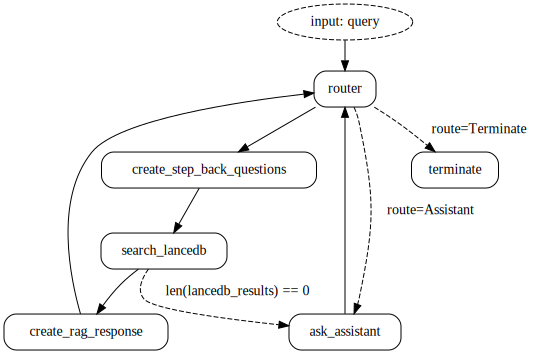

In [7]:
app.visualize(
    output_file_path="statemachine",
    include_conditions=True,
    include_state=False,
    format="png",
)

In [8]:
inputs = {"query": get_user_query()}
while True:
    action, result, state = app.step(inputs=inputs)  # type:ignore
    print(f"\nRESULT: {result}\n")
    if action.name == "terminate":
        break
    elif action.name in ["ask_assistant", "create_rag_response"]:
        inputs = {"query": get_user_query()}


RESULT: {'route': 'Soccer'}


RESULT: {'step_back_questions': ['What are the basic rules of football (soccer) regarding player positioning and movement?', 'How does the offside rule ensure fair play and prevent unfair advantages in football?', 'What are some examples of common situations where the offside rule is applied in football?']}



/home/hamza/dev/dreamai/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



RESULT: {'lancedb_results': ['**Ball Control**:\n  - Players can use any part of their body except their arms and hands to control the\nball\n  - The goalkeeper can use their hands, but only within their own penalty area\n4. **Tackling**:\n  - Players can attempt to take the ball from opponents, but must do so without\ncommitting fouls\n  - Slide tackles are allowed but risky, as mistimed attempts often result in fouls\n5. **Advantage Rule**:\n  - If a foul occurs but the fouled team retains possession with a promising attack,\nthe referee may allow play to continue rather than stopping for a free kick\nUnderstanding these basic principles of scoring and gameplay will help you follow the\nflow of a soccer match more easily.', "**Stoppage Time**: Extra time added to the end of each half to account for delays\nduring play.\n- **Striker**: A forward player whose primary role is to score goals.\n- **Tackle**: The act of taking the ball away from an opponent using the feet.\n- **Through Ba